# Notebook 12 H1 - Analysis

## Hypothesis 1: 
Quantitative analysis of terminology and key concepts in Heresies will reveal distinct temporal shifts in vocabulary corresponding to the magazine's evolving theoretical and thematic orientations, including essentialist and practice-based vocabulary in the late 1970s, increasing attention to intersectional and political concerns in the early 1980s, and a shift toward deconstructive and late-theoretical vocabulary by the early 1990s.

### Sources
- Find Frequency of Characters in Python. (23:53:17+00:00). GeeksforGeeks. https://www.geeksforgeeks.org/python/python-frequency-of-each-character-in-string/
- Line chart in Matplotlib—Python. (17:48:11+00:00). GeeksforGeeks. https://www.geeksforgeeks.org/python/line-chart-in-matplotlib-python/
- Understanding TF-IDF (Term Frequency-Inverse Document Frequency). (00:24:59+00:00). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/


### 1. Imports

In [13]:
import pandas as pd
import ast
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import chi2_contingency
import numpy as np

### 2. Loading the lemmatized corpus

In [14]:
df = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/processed/09_h1_lemmatized.csv")
df["tokens"] = df["tokens"].apply(ast.literal_eval)

### 3. Extracting the issue number and assign the volume group
(Diachronic segmentation)

In [15]:
def get_issue_number(filepath):
    match = re.search(r"heresies_(\d+)_combined", filepath)
    return int(match.group(1)) if match else None

def get_volume(issue_nr):
    if issue_nr <= 4:
        return "Vol1_1977-1978"
    elif issue_nr <= 8:
        return "Vol2_1978-1979"
    elif issue_nr <= 12:
        return "Vol3_1980-1981"
    elif issue_nr <= 16:
        return "Vol4_1981-1983"
    elif issue_nr <= 20:
        return "Vol5_1984-1985"
    elif issue_nr <= 24:
        return "Vol6_1987-1989"
    elif issue_nr <= 27:
        return "Vol7_1990-1993"
    else:
        return None

df["issue"]  = df["source_file"].apply(get_issue_number)
df["volume"] = df["issue"].apply(get_volume)

print(df["volume"].value_counts())
print(f"Total issues loaded: {df['issue'].nunique()}")
print(f"Issues present: {sorted(df['issue'].unique())}")

volume
Vol2_1978-1979    4376
Vol1_1977-1978    3706
Vol3_1980-1981    3592
Vol4_1981-1983    2868
Vol6_1987-1989    2440
Vol5_1984-1985    2384
Vol7_1990-1993    1267
Name: count, dtype: int64
Total issues loaded: 27
Issues present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


### 4. Create one text string per volume

In [16]:
# join all tokens per volume into one string
# this is needed for TF-IDF and keyword analysis

volume_texts = df.groupby("volume")["tokens"].apply(
    lambda x: " ".join([token for tokens in x for token in tokens])
)

print(volume_texts.index.tolist())

['Vol1_1977-1978', 'Vol2_1978-1979', 'Vol3_1980-1981', 'Vol4_1981-1983', 'Vol5_1984-1985', 'Vol6_1987-1989', 'Vol7_1990-1993']


## 5. Wordlists

### 5.1 Wordlist over the whole corpus
the Code in Cells 18 and 19 has been generated by Claude AI. The prompt can be found here: AI_prompts/H1_analysis_wordlist.txt

In [17]:
#### Wordlist: All Unique Terms (Exploratory)
# Generates a full wordlist across the entire corpus with raw frequency, 
# relative frequency per 1,000,000 words, and TF-IDF score per volume.

from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

# --- 1. Corpus-wide raw + relative frequency ---
all_tokens = [t for tlist in df["tokens"] for t in tlist]
total_words = len(all_tokens)
raw_counts = Counter(all_tokens)

wordlist = pd.DataFrame([
    {
        "word": word,
        "raw_frequency": count,
        "relative_frequency_per_1M": (count / total_words) * 1_000_000
    }
    for word, count in raw_counts.items()
]).sort_values("raw_frequency", ascending=False).reset_index(drop=True)

print(f"Total unique words: {len(wordlist)}")
print(f"Total corpus words: {total_words:,}")
print(wordlist.head(30))

Total unique words: 15833
Total corpus words: 80,180
        word  raw_frequency  relative_frequency_per_1M
0      woman           1639               20441.506610
1        not            664                8281.366924
2       work            589                7345.971564
3        one            516                6435.520080
4        art            464                5786.979297
5       make            360                4489.897730
6        say            351                4377.650287
7       time            340                4240.458967
8       like            313                3903.716638
9         go            309                3853.828885
10      come            293                3654.277875
11  feminist            278                3467.198803
12       get            277                3454.726865
13        no            274                3417.311050
14     first            271                3379.895236
15      year            263                3280.119731
16         u

In [18]:
# Save wordlist
wordlist.to_csv("/Users/sophiehamann/master-thesis-code/data/processed/11_h1_wordlist.csv", index=False)
print("Wordlist saved.")

Wordlist saved.


### 5.2 Wordlist per Issue

In [19]:
# Wordlist per issue
rows = []

for issue in sorted(df["issue"].dropna().unique()):
    tokens = [t for tlist in df[df["issue"] == issue]["tokens"] for t in tlist]
    total = len(tokens)
    for word, count in Counter(tokens).items():
        rows.append({
            "issue": int(issue),
            "volume": df[df["issue"] == issue]["volume"].iloc[0],  # add volume label too
            "word": word,
            "raw_frequency": count,
            "relative_frequency_per_1M": (count / total) * 1_000_000
        })

df_wordlist_by_issue = pd.DataFrame(rows)\
    .sort_values(["issue", "raw_frequency"], ascending=[True, False])\
    .reset_index(drop=True)

df_wordlist_by_issue.to_csv(
    "/Users/sophiehamann/master-thesis-code/data/processed/11_h1_wordlist_by_issue.csv",
    index=False)

print(f"Saved. Shape: {df_wordlist_by_issue.shape}")
print(df_wordlist_by_issue.head(10))

Saved. Shape: (42208, 5)
   issue          volume      word  raw_frequency  relative_frequency_per_1M
0      1  Vol1_1977-1978     woman             75               25458.248473
1      1  Vol1_1977-1978       art             37               12559.402580
2      1  Vol1_1977-1978       not             22                7467.752885
3      1  Vol1_1977-1978      work             17                5770.536320
4      1  Vol1_1977-1978      like             17                5770.536320
5      1  Vol1_1977-1978       one             17                5770.536320
6      1  Vol1_1977-1978  feminist             16                5431.093007
7      1  Vol1_1977-1978       lie             16                5431.093007
8      1  Vol1_1977-1978      tell             15                5091.649695
9      1  Vol1_1977-1978      take             14                4752.206382


In [20]:
# Save per-issue wordlist
df_wordlist_by_issue.to_csv(
    "/Users/sophiehamann/master-thesis-code/data/processed/11_h1_wordlist_by_issue.csv", 
    index=False)
print("Per-issue wordlist saved.")

Per-issue wordlist saved.


### 5.3 Wordlist per Volume

In [21]:
# count relative frequency of each word per volume
rows = []

volume_order = ["Vol1_1977-1978", "Vol2_1978-1979", "Vol3_1980-1981",
                "Vol4_1981-1983", "Vol5_1984-1985", "Vol6_1987-1989", "Vol7_1990-1993"]


for vol in volume_order:
    tokens = [t for tlist in df[df["volume"] == vol]["tokens"] for t in tlist]
    total = len(tokens)
    for word, count in Counter(tokens).items():
        rows.append({
            "volume": vol,
            "word": word,
            "relative_frequency_per_1M": (count / total) * 1_000_000
        })

df_wordlist_by_volume = pd.DataFrame(rows)
print(df_wordlist_by_volume.head(20))

            volume          word  relative_frequency_per_1M
0   Vol1_1977-1978             4                 362.537764
1   Vol1_1977-1978        devote                 422.960725
2   Vol1_1977-1978   examination                 181.268882
3   Vol1_1977-1978           art               11178.247734
4   Vol1_1977-1978        polity                  60.422961
5   Vol1_1977-1978      feminist                4108.761329
6   Vol1_1977-1978   perspective                 241.691843
7   Vol1_1977-1978       believe                 725.075529
8   Vol1_1977-1978          ming                  60.422961
9   Vol1_1977-1978    definition                 362.537764
10  Vol1_1977-1978          fun-                  60.422961
11  Vol1_1977-1978         woman               25317.220544
12  Vol1_1977-1978         aware                 483.383686
13  Vol1_1977-1978  historically                 483.383686
14  Vol1_1977-1978    connection                 604.229607
15  Vol1_1977-1978          live        

In [22]:
# Save per-volume wordlist (currently missing)
df_wordlist_by_volume.to_csv(
    "/Users/sophiehamann/master-thesis-code/data/processed/11_h1_wordlist_by_volume.csv", 
    index=False)
print("Per-volume wordlist saved.")

Per-volume wordlist saved.


### 6. Relative Frequency for key feminist terms per volume
Using this: https://www.geeksforgeeks.org/python/python-frequency-of-each-character-in-string/


This compares the same words in each diachronically segmented part. The words being looked for are pre-defined. these may need to change!

Here, the loop counts the raw occurrences and then converts these to relative frequency per 1,000 words. So if "woman" appears 80 times in a volume of 10,000 tokens, its gets (80/10000)*1000 = 8.0.
This is done because the volumes do have different sizes, so raw counts could be misleading. 

In [23]:
# these are your expected keywords from your notes
key_terms = [
    # Theoretical shift vocabulary
    "body", "woman", "difference", "language",
    "representation", "identity", "power", "sexuality",
    "nature", "culture", "construction", "discourse",
    
    # Art & practice
    "art", "artist", "image", "visual", "work", "practice",
    
    # Collective & politics (activist identity)
    "collective", "political", "community", "feminist", "movement",
    
    # Intersectionality (race & sexuality)
    "black", "race", "lesbian",
    
    # Essentialism (experience & embodiment)
    "female", "mother", "experience", "consciousness",
    
    # Late theoretical vocabulary
    "subject", "text", "writing", "theory", "gender"
]
results = []

for volume, text in volume_texts.items():
    tokens = text.split()
    total  = len(tokens)
    for term in key_terms:
        freq    = tokens.count(term)
        rel_freq = (freq / total) * 1000   # per 1000 words
        results.append({
            "volume": volume,
            "term":   term,
            "relative_frequency": rel_freq
        })

df_freq = pd.DataFrame(results)
print(df_freq.head(50))

            volume            term  relative_frequency
0   Vol1_1977-1978            body            1.389728
1   Vol1_1977-1978           woman           25.317221
2   Vol1_1977-1978      difference            0.362538
3   Vol1_1977-1978        language            0.362538
4   Vol1_1977-1978  representation            0.120846
5   Vol1_1977-1978        identity            0.181269
6   Vol1_1977-1978           power            1.087613
7   Vol1_1977-1978       sexuality            0.241692
8   Vol1_1977-1978          nature            0.483384
9   Vol1_1977-1978         culture            1.691843
10  Vol1_1977-1978    construction            0.120846
11  Vol1_1977-1978       discourse            0.000000
12  Vol1_1977-1978             art           11.178248
13  Vol1_1977-1978          artist            3.021148
14  Vol1_1977-1978           image            0.604230
15  Vol1_1977-1978          visual            0.181269
16  Vol1_1977-1978            work            8.519637
17  Vol1_1

Important argumentation about the Key terms

The selection of key terms for diachronic frequency analysis follows a theoretically motivated approach grounded in the existing scholarship on feminist theory periodization. Rather than relying exclusively on data-driven term extraction, a predefined wordlist was constructed deductively, drawing on canonical accounts of second-wave feminist theory and its successive theoretical orientations as described in the literature. The initial twelve terms — body, woman, difference, language, representation, identity, power, sexuality, nature, culture, construction, discourse — were selected to capture the three theoretical phases proposed in H1: essentialist feminism, characterized by grounding feminist politics in shared female embodiment and experience; French and difference feminism, which foregrounded language, sexuality, and cultural construction as sites of feminist intervention; and deconstructive orientations, which introduced discourse, representation, and subject formation as central analytical categories. This list was subsequently expanded to account for the specific institutional and thematic character of Heresies Magazine as an artist-activist publication, adding terms related to art practice (art, artist, image, visual), collective politics (collective, political, community), and intersectional concerns (black, race, lesbian) — categories that a purely theory-derived list would have obscured. The expanded list therefore reflects both the macro-level periodization of feminist theory and the particular discursive context of Heresies, making it defensible as neither arbitrary nor purely subjective. To complement this deductive approach, TF-IDF analysis was conducted in parallel as a data-driven method, allowing the corpus itself to surface distinctive vocabulary independent of theoretical preselection. The convergence or divergence between these two methods — predefined frequency tracking and exploratory TF-IDF — provides a basis for triangulating findings and assessing the robustness of the analytical framework.


## Visualizations
### 6.1. Line Chart of Key Terms over time
Using this: https://www.geeksforgeeks.org/python/line-chart-in-matplotlib-python/

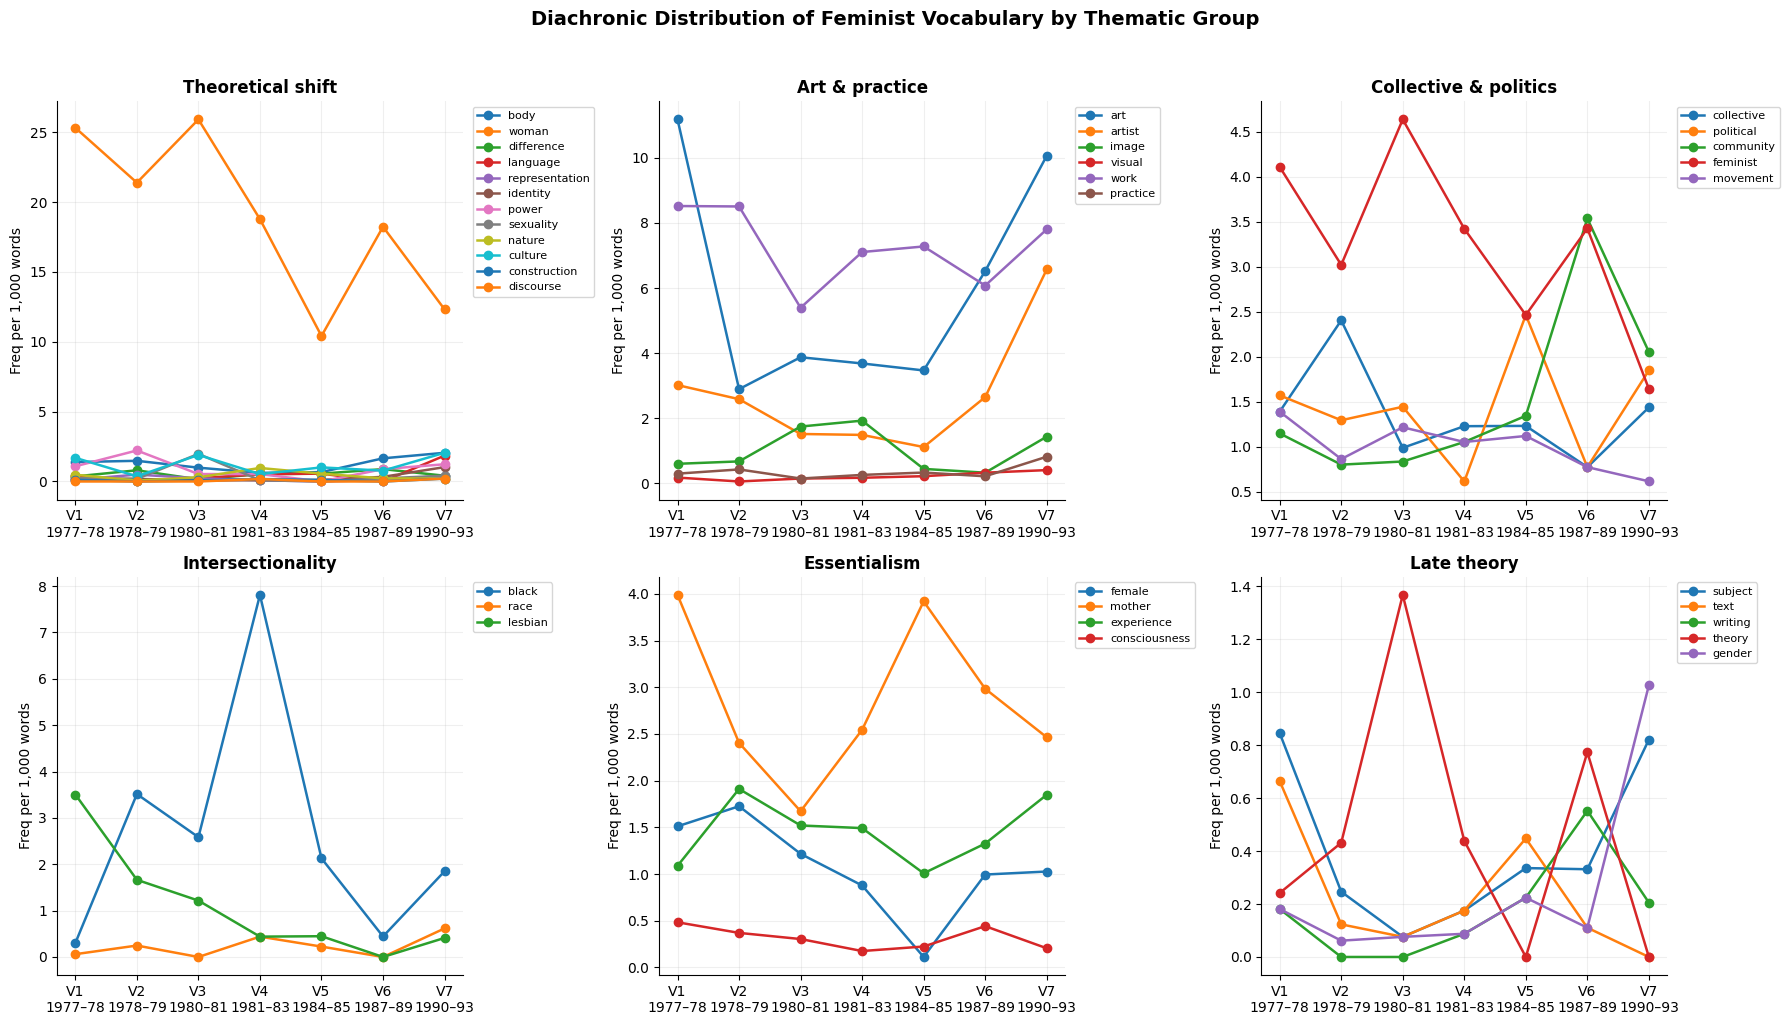

In [35]:
term_groups = {
    "Theoretical shift": ["body", "woman", "difference", "language",
                          "representation", "identity", "power", "sexuality",
                          "nature", "culture", "construction", "discourse"],
    "Art & practice":   ["art", "artist", "image", "visual", "work", "practice"],
    "Collective & politics": ["collective", "political", "community", 
                              "feminist", "movement"],
    "Intersectionality": ["black", "race", "lesbian"],
    "Essentialism":     ["female", "mother", "experience", "consciousness"],
    "Late theory":      ["subject", "text", "writing", "theory", "gender"]
}

volume_order = ["Vol1_1977-1978", "Vol2_1978-1979", "Vol3_1980-1981",
                "Vol4_1981-1983", "Vol5_1984-1985", "Vol6_1987-1989", "Vol7_1990-1993"]
short_labels  = ["V1\n1977–78", "V2\n1978–79", "V3\n1980–81", "V4\n1981–83",
                 "V5\n1984–85", "V6\n1987–89", "V7\n1990–93"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (group_name, terms) in enumerate(term_groups.items()):
    ax = axes[i]
    for term in terms:
        term_data = df_freq[df_freq["term"] == term].set_index("volume")
        values = [term_data.loc[v, "relative_frequency"] 
                  if v in term_data.index else 0 
                  for v in volume_order]
        ax.plot(short_labels, values, marker="o", linewidth=1.8, label=term)
    
    ax.set_title(group_name, fontsize=12, fontweight="bold")
    ax.set_ylabel("Freq per 1,000 words")
    ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, alpha=0.2)

plt.suptitle("Diachronic Distribution of Feminist Vocabulary by Thematic Group",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph1_frequency_by_group.png",
            bbox_inches="tight", dpi=150)
plt.show()

### 8. TF-IDF per volume
Using [this documentation for help.](https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/)

This cell finds the most distinctive words per volume. Meaning it doe not just find the most frequent words, but the ones that characterize each volume compared to the other volumes.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

extra_stopwords = ["not", "one", "make", "time", "say", "know", "also", 
                   "year", "work", "like", "get", "come", "go", "take", "use"]

vectorizer = TfidfVectorizer(max_features=50, stop_words=extra_stopwords)

tfidf_matrix = vectorizer.fit_transform(volume_texts.values)
feature_names = vectorizer.get_feature_names_out()

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=volume_texts.index,
    columns=feature_names
)

print(df_tfidf)

                  always   another       art    artist    become     begin  \
volume                                                                       
Vol1_1977-1978  0.055022  0.037946  0.351003  0.104352  0.051227  0.060714   
Vol2_1978-1979  0.064106  0.068527  0.106106  0.092843  0.048632  0.086211   
Vol3_1980-1981  0.028689  0.059769  0.126711  0.047815  0.064551  0.045425   
Vol4_1981-1983  0.031538  0.053615  0.138768  0.053615  0.066230  0.091461   
Vol5_1984-1985  0.110156  0.060586  0.181757  0.060586  0.071601  0.126679   
Vol6_1987-1989  0.072796  0.055668  0.269775  0.111336  0.072796  0.107054   
Vol7_1990-1993  0.078521  0.061072  0.427503  0.279185  0.122144  0.174491   

                   black    change     child     could  ...     think  \
volume                                                  ...             
Vol1_1977-1978  0.009487  0.030357  0.079687  0.062611  ...  0.083482   
Vol2_1978-1979  0.130422  0.066316  0.044211  0.086211  ...  0.092843   
Vol3_

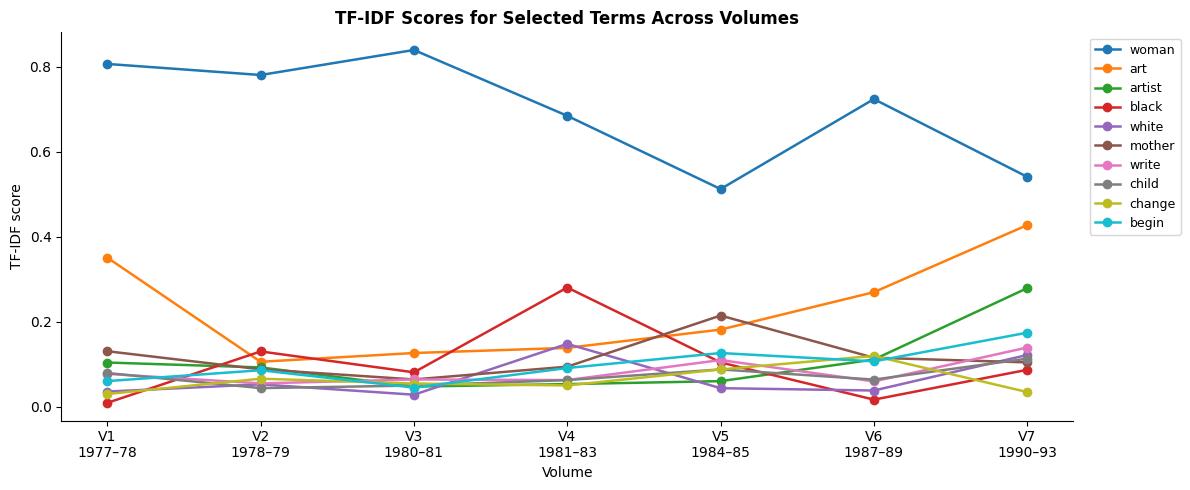

In [39]:
tracked = ["woman", "art", "artist", "black", "white", "mother", "write", "child", "change", "begin"]

fig, ax = plt.subplots(figsize=(12, 5))

for term in tracked:
    ax.plot(short_labels, df_tfidf[term].values, marker="o", linewidth=1.8, label=term)

ax.set_ylabel("TF-IDF score")
ax.set_xlabel("Volume")
ax.set_title("TF-IDF Scores for Selected Terms Across Volumes", fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_tfidf_over_time.png",
            bbox_inches="tight", dpi=150)
plt.show()

#### 9. Keyword comparison table

Printing the 20 most distinctive words for each volume ranked by their TF-IDF score. 

In [27]:
# show top 10 distinctive terms per volume
for volume in df_tfidf.index:
    print(f"\nTop keywords for {volume}:")
    print(df_tfidf.loc[volume].sort_values(ascending=False).head(10))


Top keywords for Vol1_1977-1978:
woman       0.806357
art         0.351003
feminist    0.132812
mother      0.130914
no          0.106249
artist      0.104352
men         0.100557
life        0.092968
want        0.087276
first       0.085379
Name: Vol1_1977-1978, dtype: float64

Top keywords for Vol2_1978-1979:
woman       0.780324
group       0.256424
project     0.137054
black       0.130422
no          0.128212
many        0.119370
two         0.119370
new         0.114949
feminist    0.110527
art         0.106106
Name: Vol2_1978-1979, dtype: float64

Top keywords for Vol3_1980-1981:
woman       0.839162
music       0.222221
feminist    0.148228
art         0.126711
first       0.119539
men         0.112366
no          0.109976
would       0.105194
two         0.105194
many        0.093240
Name: Vol3_1980-1981, dtype: float64

Top keywords for Vol4_1981-1983:
woman     0.684378
black     0.280690
film      0.227075
people    0.176614
no        0.163998
see       0.157691
first    

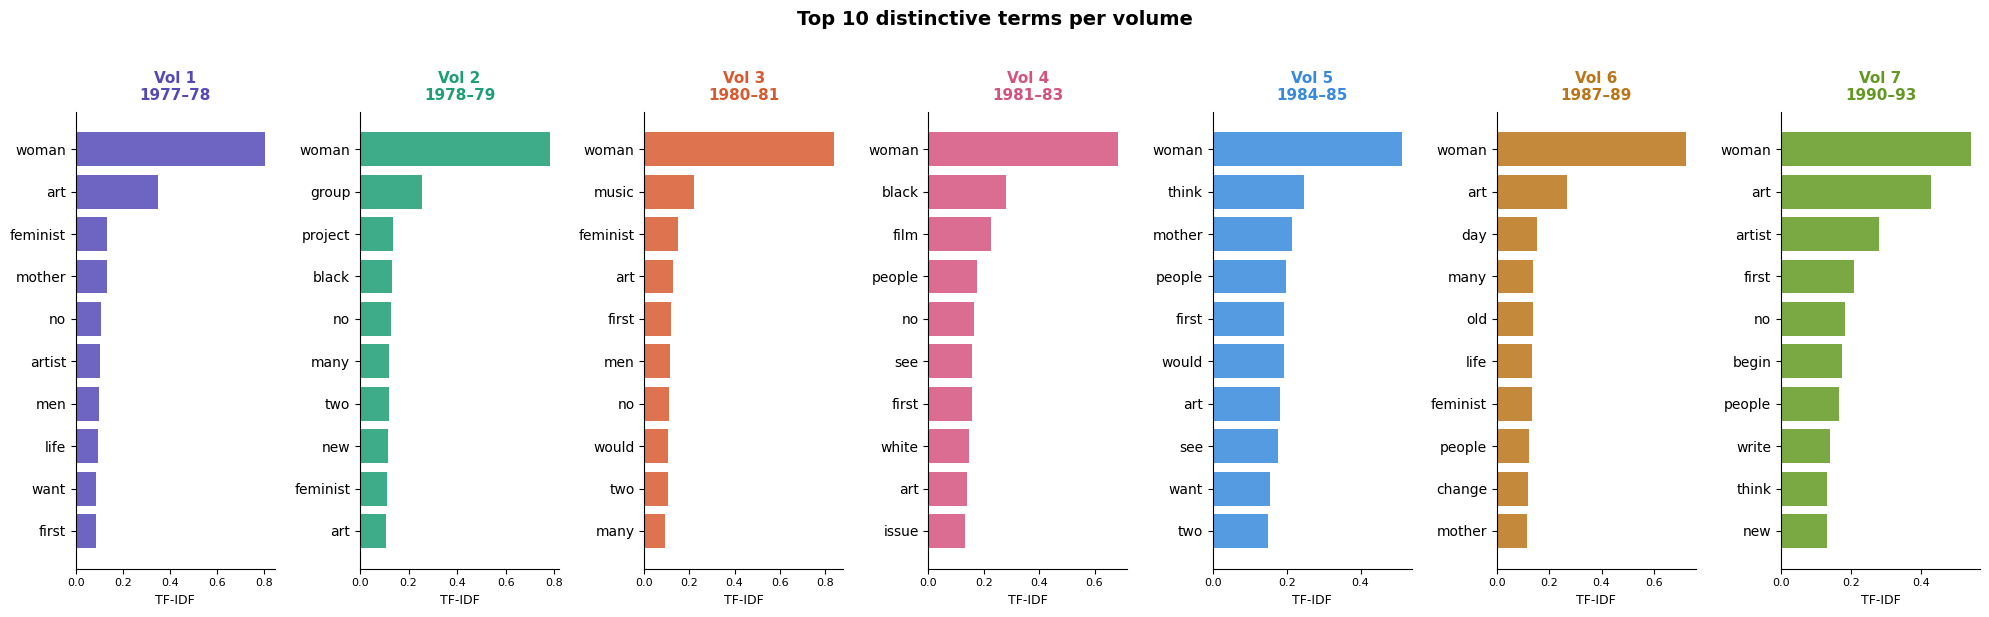

In [28]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 7, figsize=(20, 6), sharey=False)

colors = ["#534AB7", "#1D9E75", "#D85A30", "#D4537E", "#378ADD", "#BA7517", "#639922"]
labels = ["Vol 1\n1977–78", "Vol 2\n1978–79", "Vol 3\n1980–81", "Vol 4\n1981–83",
          "Vol 5\n1984–85", "Vol 6\n1987–89", "Vol 7\n1990–93"]

for i, (volume, ax) in enumerate(zip(df_tfidf.index, axes)):
    top10 = df_tfidf.loc[volume].sort_values(ascending=False).head(10)
    
    ax.barh(range(len(top10)), top10.values, color=colors[i], alpha=0.85)
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels(top10.index, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(labels[i], fontsize=11, fontweight="bold", color=colors[i], pad=8)
    ax.set_xlabel("TF-IDF", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Top 10 distinctive terms per volume", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_tfidf_per_volume.png", bbox_inches="tight", dpi=150)
plt.show()

#### 10. Saving the Frequency results

In [29]:
df_freq.to_csv("/Users/sophiehamann/master-thesis-code/data/processed/11_h1_frequency.csv", index=False)
df_tfidf.to_csv("/Users/sophiehamann/master-thesis-code/data/processed/11_h1_tfidf.csv", index=False)

### 11. N-Gram Analysis per Volume (Bigrams & Trigrams)
The following Analysis has been done with Claude. You can find the prompt here: /Users/sophiehamann/master-thesis-code/notebooks/AI_prompts/h1_12_n-gram_analysis_prompt.txt

To complement the single-word frequency and TF-IDF analysis, this section examines
which bigrams and trigrams are most characteristic per volume. This tests whether
multi-word phrases show the same temporal drift as individual tokens.

#### 11.1 Load Data and build per-volume n-gram counts

In [30]:
import ast
from nltk.util import ngrams
from collections import Counter

# Load the filtered ngram lists from notebook 11
df_bigrams_all  = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/processed/10_h1_bigrams.csv")
df_trigrams_all = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/processed/10_h1_trigrams.csv")

# Convert string tuples back to actual tuples
df_bigrams_all["bigram"]   = df_bigrams_all["bigram"].apply(ast.literal_eval)
df_trigrams_all["trigram"] = df_trigrams_all["trigram"].apply(ast.literal_eval)

# Keep only the ngrams that passed the cutoff in nb11
valid_bigrams  = set(df_bigrams_all["bigram"].tolist())
valid_trigrams = set(df_trigrams_all["trigram"].tolist())

# Count bigrams and trigrams per volume using the lemmatized corpus (df already loaded)
volume_order = ["Vol1_1977-1978", "Vol2_1978-1979", "Vol3_1980-1981",
                "Vol4_1981-1983", "Vol5_1984-1985", "Vol6_1987-1989", "Vol7_1990-1993"]

bigram_counts  = {}   # {volume: Counter}
trigram_counts = {}

for vol in volume_order:
    tokens = [t for tlist in df[df["volume"] == vol]["tokens"] for t in tlist]
    bigram_counts[vol]  = Counter(bg for bg in ngrams(tokens, 2) if bg in valid_bigrams)
    trigram_counts[vol] = Counter(tg for tg in ngrams(tokens, 3) if tg in valid_trigrams)

print("Bigram/trigram counts per volume computed.")

Bigram/trigram counts per volume computed.


#### 11.2 Visualization 1: Top bigrams per volume (heatmap-style bar charts):

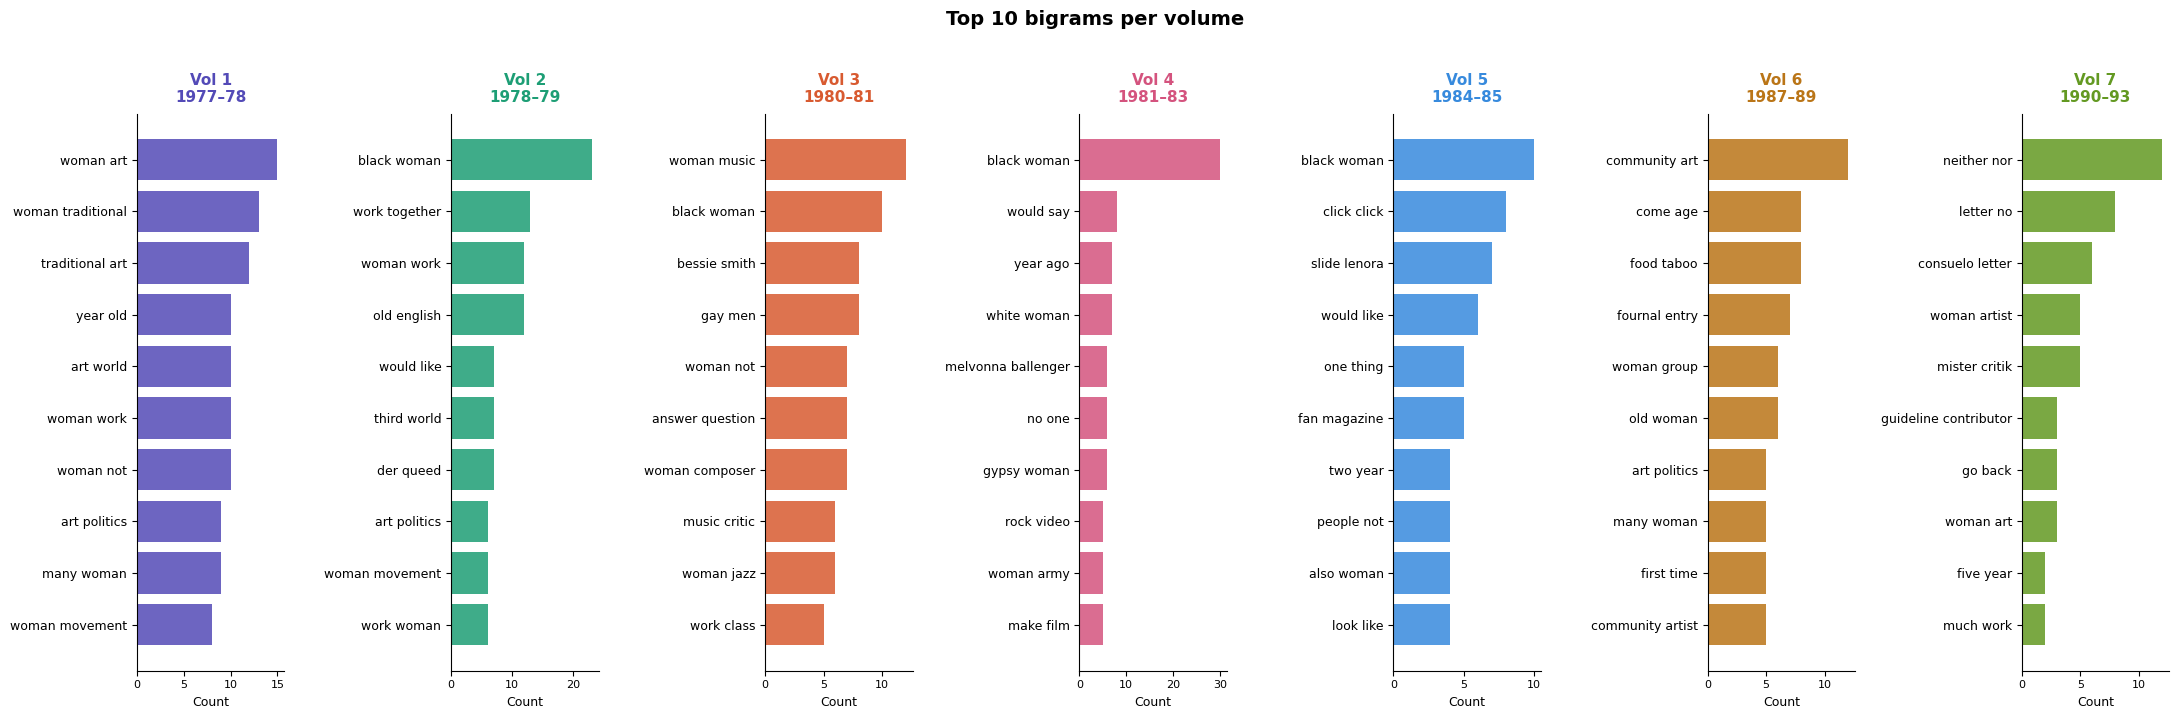

In [31]:
fig, axes = plt.subplots(1, 7, figsize=(22, 7), sharey=False)

colors = ["#534AB7", "#1D9E75", "#D85A30", "#D4537E", "#378ADD", "#BA7517", "#639922"]
labels = ["Vol 1\n1977–78", "Vol 2\n1978–79", "Vol 3\n1980–81", "Vol 4\n1981–83",
          "Vol 5\n1984–85", "Vol 6\n1987–89", "Vol 7\n1990–93"]

for i, (vol, ax) in enumerate(zip(volume_order, axes)):
    top = bigram_counts[vol].most_common(10)
    if not top:
        ax.set_visible(False)
        continue
    phrases, freqs = zip(*top)
    phrase_labels  = [" ".join(p) for p in phrases]

    ax.barh(range(len(phrases)), freqs, color=colors[i], alpha=0.85)
    ax.set_yticks(range(len(phrases)))
    ax.set_yticklabels(phrase_labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(labels[i], fontsize=11, fontweight="bold", color=colors[i], pad=8)
    ax.set_xlabel("Count", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Top 10 bigrams per volume", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_bigrams_per_volume.png",
            bbox_inches="tight", dpi=150)
plt.show()

#### 11.3 Visualization 2: Tracking selected H1-relevant bigrams over time (line chart):

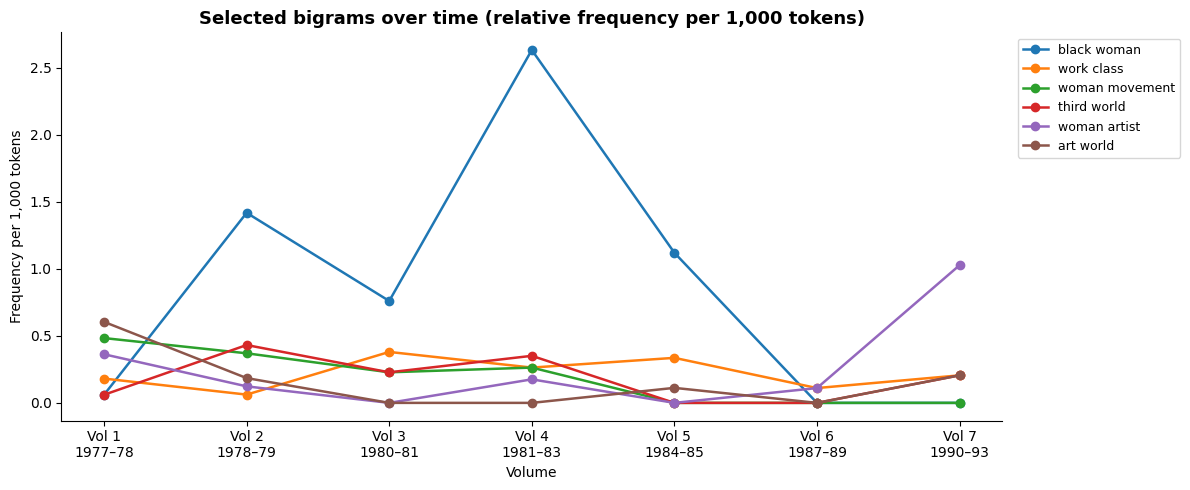

In [32]:
# These bigrams are theoretically motivated for H1

tracked_bigrams = [
    ("black", "woman"),       #black feminism & intersectionality
    ("work", "class"),        #class politics
    ("woman", "movement"),    #second wave vocabulary
    ("third", "world"),       #intersectionality
    ("woman", "artist"),      #art identity
    ("art", "world"),         #art world engagement
]

# Normalize by total tokens per volume to get relative frequency (per 1000 tokens)
vol_token_counts = {
    vol: sum(len(tlist) for tlist in df[df["volume"] == vol]["tokens"])
    for vol in volume_order
}

fig, ax = plt.subplots(figsize=(12, 5))

for bg in tracked_bigrams:
    freqs = [
        bigram_counts[vol].get(bg, 0) / vol_token_counts[vol] * 1000
        for vol in volume_order
    ]
    ax.plot(labels, freqs, marker="o", label=" ".join(bg), linewidth=1.8)

ax.set_title("Selected bigrams over time (relative frequency per 1,000 tokens)", fontsize=13, fontweight="bold")
ax.set_ylabel("Frequency per 1,000 tokens")
ax.set_xlabel("Volume")
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_bigrams_over_time.png",
            bbox_inches="tight", dpi=150)
plt.show()

#### 11.4  Trigrams per volume (same bar chart pattern):

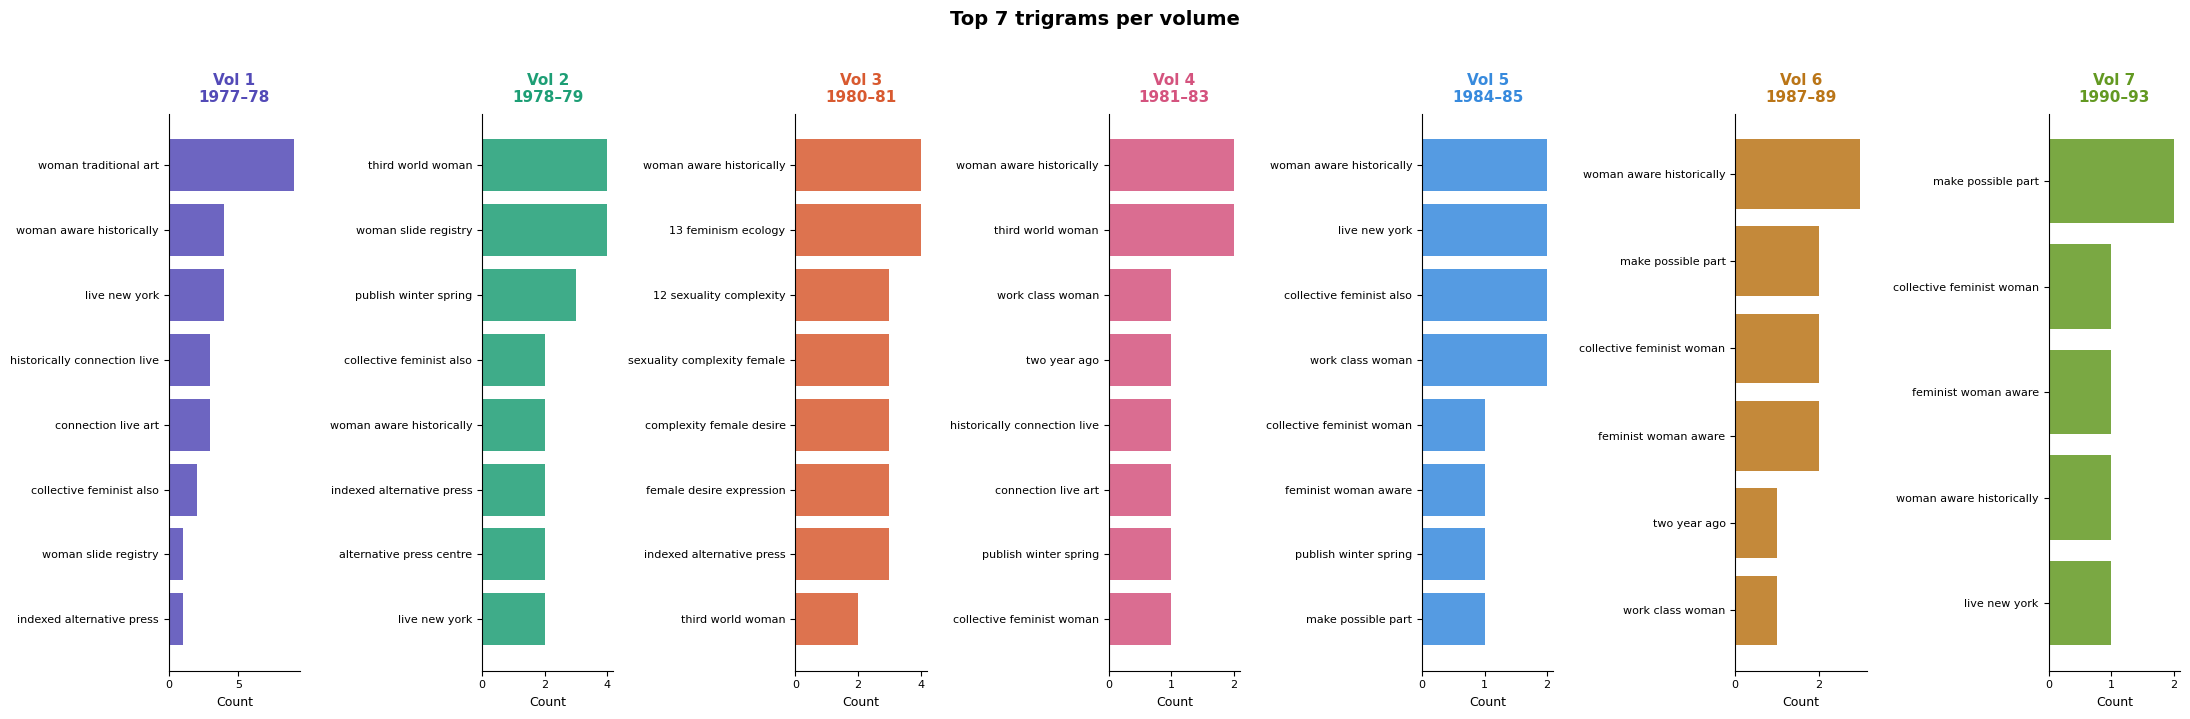

In [33]:
fig, axes = plt.subplots(1, 7, figsize=(22, 7), sharey=False)

for i, (vol, ax) in enumerate(zip(volume_order, axes)):
    top = trigram_counts[vol].most_common(8)
    if not top:
        ax.axis("off")
        ax.set_title(labels[i], fontsize=11, fontweight="bold", color=colors[i], pad=8)
        continue
    phrases, freqs = zip(*top)
    phrase_labels  = [" ".join(p) for p in phrases]

    ax.barh(range(len(phrases)), freqs, color=colors[i], alpha=0.85)
    ax.set_yticks(range(len(phrases)))
    ax.set_yticklabels(phrase_labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(labels[i], fontsize=11, fontweight="bold", color=colors[i], pad=8)
    ax.set_xlabel("Count", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Top 7 trigrams per volume", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_trigrams_per_volume.png",
            bbox_inches="tight", dpi=150)
plt.show()

#### 11.5 Tracking selected H1-relevant trigrams over time (line chart):

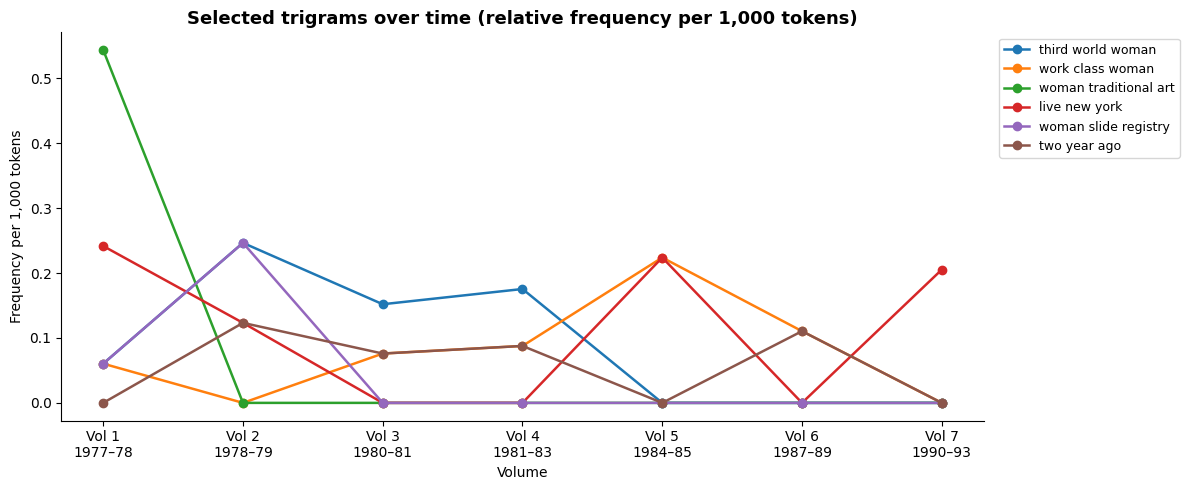

In [34]:
# These trigrams are theoretically motivated for H1
# These trigrams are theoretically motivated for H1
tracked_trigrams = [
    ("third", "world", "woman"),      # intersectionality
    ("work", "class", "woman"),       # class politics
    ("woman", "traditional", "art"),  # art & gender
    ("live", "new", "york"),          # geographic community
    ("woman", "slide", "registry"),   # feminist art infrastructure
    ("two", "year", "ago"),           # temporal reference
]

# vol_token_counts already computed above

fig, ax = plt.subplots(figsize=(12, 5))

for tg in tracked_trigrams:
    freqs = [
        trigram_counts[vol].get(tg, 0) / vol_token_counts[vol] * 1000
        for vol in volume_order
    ]
    ax.plot(labels, freqs, marker="o", label=" ".join(tg), linewidth=1.8)

ax.set_title("Selected trigrams over time (relative frequency per 1,000 tokens)", fontsize=13, fontweight="bold")
ax.set_ylabel("Frequency per 1,000 tokens")
ax.set_xlabel("Volume")
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_trigrams_over_time.png",
            bbox_inches="tight", dpi=150)
plt.show()